#Importing All Dependencies

In [ ]:
##Installing PyTorch Geometric
!pip install torch_geometric
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.2.0+cu121.html



Looking in links: https://data.pyg.org/whl/torch-2.2.0+cu121.html


In [ ]:
!pip install implicit

In [ ]:
## DOUBLE CHECKING THAT IT WORKED
import torch_geometric
print(torch_geometric.__version__)


2.7.0


In [ ]:
import os
import kagglehub
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data
from torch_geometric.utils import k_hop_subgraph, to_undirected
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


#Downloading Kaggle Dataset

In [ ]:
path = kagglehub.dataset_download("retailrocket/ecommerce-dataset")
events_path = os.path.join(path, "events.csv")
events = pd.read_csv(events_path)
events = events[['visitorid', 'itemid', 'timestamp', 'event']].dropna()
events = events.sort_values('timestamp').reset_index(drop=True)
print("Total events:", len(events))

events = events.sample(n=50000, random_state=42).sort_values('timestamp').reset_index(drop=True)
print(len(events))
events.head()



Using Colab cache for faster access to the 'ecommerce-dataset' dataset.
Total events: 2756101
50000


,visitorid,itemid,timestamp,event
0,340221,62950,1430622284504,view
1,369022,89046,1430622872999,view
2,1382643,297336,1430622883503,view
3,370260,386716,1430623230710,view
4,834374,243250,1430623658415,view


In [ ]:
## for MFmapping
mf_user_ids = events['visitorid'].astype('category').cat.codes
mf_item_ids = events['itemid'].astype('category').cat.codes

events['mf_user'] = mf_user_ids
events['mf_item'] = mf_item_ids

num_mf_users = events['mf_user'].max() + 1
num_mf_items = events['mf_item'].max() + 1


# Mapping Users and Items to Node Indices

In [ ]:
user_ids = events['visitorid'].unique()
item_ids = events['itemid'].unique()

user_id_map = {uid: i for i, uid in enumerate(user_ids)}
num_users = len(user_ids)

item_id_map = {iid: num_users + i for i, iid in enumerate(item_ids)}
num_items = len(item_ids)

num_nodes = num_users + num_items
print("Users:", num_users, "| Items:", num_items, "| Total nodes:", num_nodes)

events['user_idx'] = events['visitorid'].map(user_id_map)
events['item_idx'] = events['itemid'].map(item_id_map)
USE_EDGE_WEIGHTS = True

event_weight_map = {
    'view': 1.0,
    'addtocart': 2.0,
    'transaction': 3.0
}


if USE_EDGE_WEIGHTS:
    events['weight'] = events['event'].map(event_weight_map).fillna(1.0)
else:
    events['weight'] = 1.0

edge_src = torch.tensor(events['user_idx'].values, dtype=torch.long)
edge_dst = torch.tensor(events['item_idx'].values, dtype=torch.long)
edge_index = torch.stack([edge_src, edge_dst], dim=0)
edge_weight = torch.tensor(events['weight'].values, dtype=torch.float)

deg = torch.zeros(num_nodes, dtype=torch.float)
deg.index_add_(0, edge_src, torch.ones_like(edge_src, dtype=torch.float))
deg.index_add_(0, edge_dst, torch.ones_like(edge_dst, dtype=torch.float))

data = Data(
    edge_index=edge_index,
    edge_weight=edge_weight,
    x=deg.view(-1, 1),
    num_nodes=num_nodes
)

print(data)



Users: 45379 | Items: 30961 | Total nodes: 76340
Data(x=[76340, 1], edge_index=[2, 50000], edge_weight=[50000], num_nodes=76340)


#Dataset Verification

In [ ]:
user_degrees = np.bincount(events['user_idx'].values, minlength=num_nodes)[:num_users]
item_degrees = np.bincount(events['item_idx'].values, minlength=num_nodes)[num_users:]

print("User degree info: min =", user_degrees.min(), "max =", user_degrees.max(), "mean =", user_degrees.mean())
print("Item degree info: min =", item_degrees.min(), "max =", item_degrees.max(), "mean =", item_degrees.mean())


User degree info: min = 1 max = 141 mean = 1.1018312435267414
Item degree info: min = 1 max = 65 mean = 1.6149349181227997


# Encode Interaction Weights

In [ ]:
data = Data(
    edge_index=edge_index,
    edge_weight=edge_weight,
    num_nodes=num_nodes
)

##Simple node identity
deg = torch.zeros(num_nodes, dtype=torch.float)
deg.index_add_(0, edge_src, torch.ones_like(edge_src, dtype=torch.float))
deg.index_add_(0, edge_dst, torch.ones_like(edge_dst, dtype=torch.float))

data.x = deg.view(-1, 1)

data


Data(edge_index=[2, 50000], edge_weight=[50000], num_nodes=76340, x=[76340, 1])

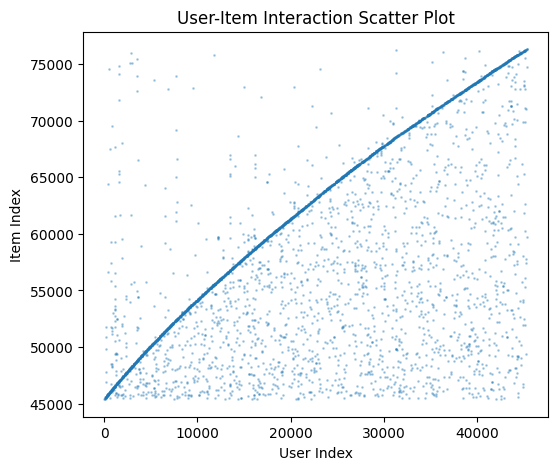

In [ ]:
sample = events.sample(n=5000, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(sample['user_idx'], sample['item_idx'], s=1, alpha=0.3)
plt.title("User-Item Interaction Scatter Plot")
plt.xlabel("User Index")
plt.ylabel("Item Index")
plt.show()


# Temporal Split!

In [ ]:
events_sorted = events.sort_values('timestamp')
n = len(events_sorted)
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

train_df = events_sorted.iloc[:train_end]
val_df   = events_sorted.iloc[train_end:val_end]
test_df  = events_sorted.iloc[val_end:]


In [ ]:
events_sorted = events.sort_values('timestamp')

n = len(events_sorted)
train_end = int(0.6 * n)
val_end   = int(0.8 * n)

train_df = events_sorted.iloc[:train_end]
val_df   = events_sorted.iloc[train_end:val_end]
test_df  = events_sorted.iloc[val_end:]

print("Temporal 60/20/20 Split:")
print("  Train:", len(train_df))
print("  Val  :", len(val_df))
print("  Test :", len(test_df))

train_edges = train_df[['user_idx', 'item_idx']].values
val_edges   = val_df[['user_idx', 'item_idx']].values
test_edges  = test_df[['user_idx', 'item_idx']].values

print("Subsampled edges for GNN:")
train_edges = train_edges[:5000]
val_edges   = val_edges[:2000]
test_edges  = test_edges[:2000]
print("  Train:", len(train_edges))
print("  Val  :", len(val_edges))
print("  Test :", len(test_edges))

## had a lot of issues trying to get it to run  based on month.




Temporal 60/20/20 Split:
  Train: 30000
  Val  : 10000
  Test : 10000
Subsampled edges for GNN:
  Train: 5000
  Val  : 2000
  Test : 2000


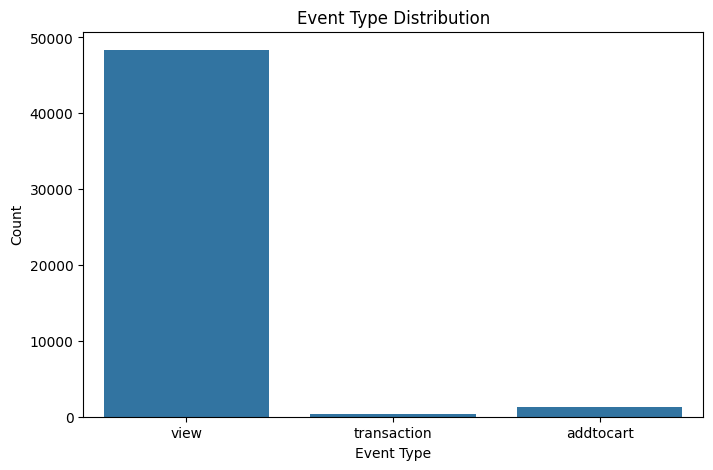

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='event', data=events)
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()


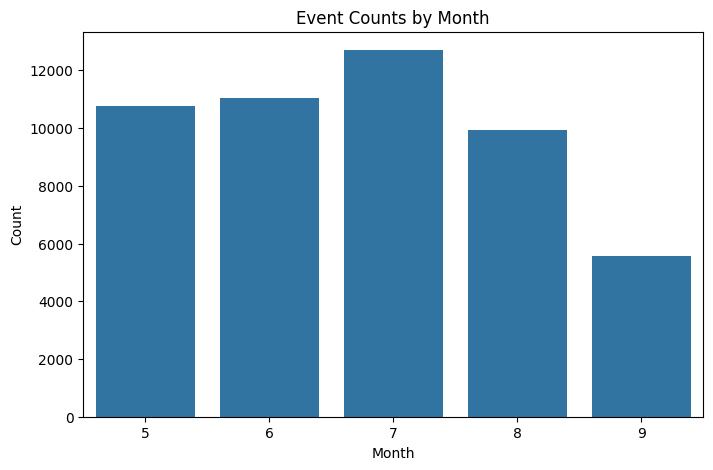

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['month'] = events['datetime'].dt.month

plt.figure(figsize=(8,5))
sns.countplot(x='month', data=events,
              order=sorted(events['month'].unique()))
plt.title("Event Counts by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


# Negative Sampling (Tentative)

In [ ]:
rng = np.random.default_rng(42)

all_pos_pairs = set((int(u), int(i)) for u, i in events[['user_idx', 'item_idx']].values)
def sample_negative_edges(num_samples, existing_edges_set):
    neg_edges = []
    while len(neg_edges) < num_samples:
        u = rng.integers(0, num_users)           # user range
        i = rng.integers(num_users, num_nodes)   # item range
        if (int(u), int(i)) not in existing_edges_set:
            neg_edges.append((int(u), int(i)))
    return np.array(neg_edges, dtype=np.int64)

num_train_pos = train_edges.shape[0]
num_val_pos   = val_edges.shape[0]
num_test_pos  = test_edges.shape[0]

train_neg_edges = sample_negative_edges(num_train_pos, all_pos_pairs)
val_neg_edges   = sample_negative_edges(num_val_pos,   all_pos_pairs)
test_neg_edges  = sample_negative_edges(num_test_pos,  all_pos_pairs)

print("Train neg:", train_neg_edges.shape[0])
print("Val neg  :", val_neg_edges.shape[0])
print("Test neg :", test_neg_edges.shape[0])



Train neg: 5000
Val neg  : 2000
Test neg : 2000


#DRNL helper from Zhang and Chen

In [ ]:
from collections import deque
undirected_edge_index = to_undirected(data.edge_index)

def drnl_labeling(sub_nodes, u_idx, v_idx):
    """
    Double-radius node labeling (DRNL) algorithm.
    """
    node_id_to_pos = {int(n): i for i, n in enumerate(sub_nodes.tolist())}
    num_sub_nodes = sub_nodes.size(0)

    ##Building adjacency list for subgraph
    adj = [[] for _ in range(num_sub_nodes)]
    ei = undirected_edge_index
    mask = torch.isin(ei[0], sub_nodes) & torch.isin(ei[1], sub_nodes)
    sub_e0 = ei[0][mask]
    sub_e1 = ei[1][mask]

    for a, b in zip(sub_e0.tolist(), sub_e1.tolist()):
        ia = node_id_to_pos[a]
        ib = node_id_to_pos[b]
        adj[ia].append(ib)
        adj[ib].append(ia)

    def bfs_dist(start_pos):
        dist = [float('inf')] * num_sub_nodes
        q = deque()
        dist[start_pos] = 0
        q.append(start_pos)
        while q:
            cur = q.popleft()
            for nb in adj[cur]:
                if dist[nb] == float('inf'):
                    dist[nb] = dist[cur] + 1
                    q.append(nb)
        return dist

    u_pos = node_id_to_pos[int(u_idx)]
    v_pos = node_id_to_pos[int(v_idx)]

    du_list = bfs_dist(u_pos)
    dv_list = bfs_dist(v_pos)

    du = torch.tensor(du_list, dtype=torch.float)
    dv = torch.tensor(dv_list, dtype=torch.float)

    big = 1e6
    du[torch.isinf(du)] = big
    dv[torch.isinf(dv)] = big

    du = du.long()
    dv = dv.long()

    dist_sum = du + dv
    dist_min = torch.min(du, dv)
    dist_sum_half = dist_sum // 2

    labels = 1 + dist_min + dist_sum_half * (dist_sum_half + 1)

    u_pos_t = torch.tensor(u_pos, dtype=torch.long)
    v_pos_t = torch.tensor(v_pos, dtype=torch.long)
    labels[u_pos_t] = 1
    labels[v_pos_t] = 1

    return labels

def extract_enclosing_subgraph(u, v, h, data):
    """
    Extract subgraph and add DRNL labels
    """
    center_nodes = torch.tensor([u, v], dtype=torch.long)
    node_idx, sub_edge_index, _, _ = k_hop_subgraph(
        center_nodes, h, undirected_edge_index, relabel_nodes=True
    )

    x_sub = data.x[node_idx]
    original_nodes = node_idx
    labels = drnl_labeling(original_nodes, u, v)

    labels_norm = labels.view(-1, 1).float()
    x_with_labels = torch.cat([x_sub, labels_norm], dim=1)

    batch = torch.zeros(x_with_labels.size(0), dtype=torch.long)
    return x_with_labels, sub_edge_index, batch


#Collating for DataLoader

In [ ]:
class LinkSubgraphDataset(Dataset):
    def __init__(self, pos_edges, neg_edges, data, h=1):
        self.pos_edges = pos_edges
        self.neg_edges = neg_edges
        self.data = data
        self.h = h

        self.edges = np.concatenate([pos_edges, neg_edges], axis=0)
        self.labels = np.concatenate([
            np.ones(len(pos_edges), dtype=np.int64),
            np.zeros(len(neg_edges), dtype=np.int64)
        ], axis=0)

    def __len__(self):
        return len(self.edges)

    def __getitem__(self, idx):
        u, v = self.edges[idx]
        y = self.labels[idx]

        x_sub, sub_edge_index, batch = extract_enclosing_subgraph(
            int(u), int(v), self.h, self.data
        )
        return x_sub, sub_edge_index, batch, torch.tensor(y, dtype=torch.float)

def collate_subgraphs(batch):
    xs, eis, batches, ys = zip(*batch)

    ys = torch.stack(ys, dim=0)

    new_x = []
    new_edge_index = []
    new_batch = []

    node_offset = 0
    batch_offset = 0
    for x_sub, ei_sub, b_sub in zip(xs, eis, batches):
        n = x_sub.size(0)
        new_x.append(x_sub)
        new_edge_index.append(ei_sub + node_offset)
        new_batch.append(b_sub + batch_offset)

        node_offset += n
        batch_offset = new_batch[-1].max().item() + 1

    new_x = torch.cat(new_x, dim=0)
    new_edge_index = torch.cat(new_edge_index, dim=1)
    new_batch = torch.cat(new_batch, dim=0)

    return new_x, new_edge_index, new_batch, ys


#Building datasets

In [ ]:
train_dataset = LinkSubgraphDataset(train_edges, train_neg_edges, data, h=1)
val_dataset   = LinkSubgraphDataset(val_edges,   val_neg_edges,   data, h=1)
test_dataset  = LinkSubgraphDataset(test_edges,  test_neg_edges,  data, h=1)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          collate_fn=collate_subgraphs)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          collate_fn=collate_subgraphs)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          collate_fn=collate_subgraphs)

len(train_dataset), len(val_dataset), len(test_dataset)


(10000, 4000, 4000)

#Model Def for baseline

In [ ]:
import scipy.sparse as sp
import implicit

rows = train_df['mf_user'].values
cols = train_df['mf_item'].values
vals = np.ones_like(rows, dtype=np.float32)

user_item_matrix = sp.coo_matrix(
    (vals, (rows, cols)),
    shape=(num_mf_users, num_mf_items)
).tocsr()

print("MF matrix shape:", user_item_matrix.shape)

als_model = implicit.als.AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=10,
    use_gpu=True
)

als_model.fit(user_item_matrix.T)


MF matrix shape: (45379, 30961)


/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.0006201267242431641 seconds
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

Matrix Factorization evaluation

In [ ]:
val_mf = val_df[['mf_user', 'mf_item']].copy()
test_mf = test_df[['mf_user', 'mf_item']].copy()

max_mf_user_id = als_model.user_factors.shape[0]
val_mf = val_mf[val_mf["mf_user"] < max_mf_user_id]
test_mf = test_mf[test_mf["mf_user"] < max_mf_user_id]

print("ALS trained on users: 0 to", max_mf_user_id - 1)
print("Val interactions:", len(val_mf))
print("Test interactions:", len(test_mf))


train_counts = train_df.groupby('mf_user').size()
active_users = train_counts[train_counts >= 3].index

val_mf_active = val_mf[val_mf['mf_user'].isin(active_users)]
test_mf_active = test_mf[test_mf['mf_user'].isin(active_users)]

print("\nActive Val interactions:", len(val_mf_active))
print("Active Test interactions:", len(test_mf_active))



def recall_ndcg_at_k_mf(model, eval_df, k=10):

    # Map users → sets of true items
    user_to_eval_items = eval_df.groupby('mf_user')['mf_item'].apply(set)

    recalls, ndcgs = [], []

    for u, true_items in user_to_eval_items.items():

        recs = model.recommend(
            userid=u,
            user_items=user_item_matrix[u],
            N=k,
            filter_already_liked_items=True
        )

        if isinstance(recs, np.ndarray):
            rec_items = recs[:, 0].tolist()
        else:
            rec_items = [r[0] for r in recs]

        hits = len(true_items.intersection(rec_items))
        recall = hits / max(1, len(true_items))
        recalls.append(recall)

        dcg = sum(
            1.0 / np.log2(rank + 1)
            for rank, item in enumerate(rec_items, 1)
            if item in true_items
        )

        idcg = sum(
            1.0 / np.log2(rank + 1)
            for rank in range(1, min(k, len(true_items)) + 1)
        )

        ndcg = dcg / idcg if idcg > 0 else 0
        ndcgs.append(ndcg)

    return np.mean(recalls), np.mean(ndcgs)



val_recall, val_ndcg = recall_ndcg_at_k_mf(als_model, val_mf_active, k=10)
test_recall, test_ndcg = recall_ndcg_at_k_mf(als_model, test_mf_active, k=10)

print("\nActive-user MF Results:")
print(f"Val  Recall@10={val_recall:.4f}, NDCG@10={val_ndcg:.4f}")
print(f"Test Recall@10={test_recall:.4f}, NDCG@10={test_ndcg:.4f}")


ALS trained on users: 0 to 30960
Val interactions: 6765
Test interactions: 6873

Active Val interactions: 175
Active Test interactions: 118

Active-user MF Results:
Val  Recall@10=0.0000, NDCG@10=0.0000
Test Recall@10=0.0000, NDCG@10=0.0000


LogReg Baseline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

def build_edge_feature_matrix(pos_edges, neg_edges):

    edges = np.concatenate([pos_edges, neg_edges], axis=0)
    labels = np.concatenate([
        np.ones(len(pos_edges), dtype=int),
        np.zeros(len(neg_edges), dtype=int)
    ], axis=0)

    user_idx = edges[:, 0]
    item_idx = edges[:, 1]

    user_deg = user_degrees[user_idx]
    item_deg = item_degrees[item_idx - num_users]

    X = np.vstack([
        user_idx,
        item_idx,
        user_deg,
        item_deg
    ]).T

    return X, labels

X_train_lr, y_train_lr = build_edge_feature_matrix(train_edges, train_neg_edges)
X_val_lr,   y_val_lr   = build_edge_feature_matrix(val_edges,   val_neg_edges)
X_test_lr,  y_test_lr  = build_edge_feature_matrix(test_edges,  test_neg_edges)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_lr, y_train_lr)

val_probs = lr.predict_proba(X_val_lr)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)
val_auc_lr = roc_auc_score(y_val_lr, val_probs)
val_f1_lr  = f1_score(y_val_lr, val_preds)
val_acc_lr = accuracy_score(y_val_lr, val_preds)

test_probs = lr.predict_proba(X_test_lr)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)
test_auc_lr = roc_auc_score(y_test_lr, test_probs)
test_f1_lr  = f1_score(y_test_lr, test_preds)
test_acc_lr = accuracy_score(y_test_lr, test_preds)

print(f"LR Val:  AUC={val_auc_lr:.4f}, F1={val_f1_lr:.4f}, ACC={val_acc_lr:.4f}")
print(f"LR Test: AUC={test_auc_lr:.4f}, F1={test_f1_lr:.4f}, ACC={test_acc_lr:.4f}")


LR Val:  AUC=0.3805, F1=0.0048, ACC=0.4818
LR Test: AUC=0.1937, F1=0.0067, ACC=0.4828


GCN Baseline + Hybrid

In [ ]:
class BaselineGCNSubgraphEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_layers=2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, batch):
        h = x
        for conv in self.convs:
            h = conv(h, edge_index)
            h = torch.relu(h)
        hg = global_mean_pool(h, batch)
        logit = self.mlp(hg).view(-1)
        return logit


class GATOnlySubgraphEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_layers=2, heads=4):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden_channels, heads=heads, concat=False))
        for _ in range(num_layers - 1):
            self.convs.append(GATConv(hidden_channels, hidden_channels, heads=heads, concat=False))

        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, batch):
        h = x
        for conv in self.convs:
            h = conv(h, edge_index)
            h = torch.relu(h)
        hg = global_mean_pool(h, batch)
        logit = self.mlp(hg).view(-1)
        return logit


class PGADRLSubgraphEncoder(nn.Module):
    """
    Hybrid GCN + GAT (PGA-DRL-style).
    """
    def __init__(self, in_channels, hidden_channels=64, num_layers=2, heads=4):
        super().__init__()
        self.gcn_convs = nn.ModuleList()
        self.gcn_convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.gcn_convs.append(GCNConv(hidden_channels, hidden_channels))
        self.gat_convs = nn.ModuleList()
        self.gat_convs.append(GATConv(in_channels, hidden_channels, heads=heads, concat=False))
        for _ in range(num_layers - 1):
            self.gat_convs.append(GATConv(hidden_channels, hidden_channels, heads=heads, concat=False))

        embed_dim = 2 * hidden_channels
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, batch):
        gcn_x = x
        for conv in self.gcn_convs:
            gcn_x = conv(gcn_x, edge_index)
            gcn_x = torch.relu(gcn_x)

        gat_x = x
        for conv in self.gat_convs:
            gat_x = conv(gat_x, edge_index)
            gat_x = torch.relu(gat_x)

        gcn_pool = global_mean_pool(gcn_x, batch)
        gat_pool = global_mean_pool(gat_x, batch)

        h = torch.cat([gcn_pool, gat_pool], dim=-1)
        logit = self.mlp(h).view(-1)
        return logit


#Creating model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()

def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    all_logits = []
    all_labels = []
    total_loss = 0.0

    for x, edge_index, batch, y in loader:
        x = x.to(device)
        edge_index = edge_index.to(device)
        batch = batch.to(device)
        y = y.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(x, edge_index, batch)
        loss = criterion(logits, y)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * y.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(y.detach().cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

    probs = torch.sigmoid(all_logits).numpy()
    preds = (probs >= 0.5).astype(int)
    true = all_labels.numpy().astype(int)

    try:
        auc = roc_auc_score(true, probs)
    except ValueError:
        auc = np.nan

    f1 = f1_score(true, preds)
    acc = accuracy_score(true, preds)
    avg_loss = total_loss / len(true)

    return avg_loss, auc, f1, acc


#Sample Batch (Having Issues)

In [ ]:
in_channels = 2  ##for the dnrl labels
num_epochs = 5

gcn_model = BaselineGCNSubgraphEncoder(in_channels=in_channels).to(device)
gcn_opt = torch.optim.Adam(gcn_model.parameters(), lr=1e-3)

gat_model = GATOnlySubgraphEncoder(in_channels=in_channels).to(device)
gat_opt = torch.optim.Adam(gat_model.parameters(), lr=1e-3)

hybrid_model = PGADRLSubgraphEncoder(in_channels=in_channels).to(device)
hybrid_opt = torch.optim.Adam(hybrid_model.parameters(), lr=1e-3)


print("GCN Training")
for epoch in range(1, num_epochs + 1):
    train_loss, train_auc, train_f1, train_acc = run_epoch(train_loader, gcn_model, gcn_opt)
    val_loss, val_auc, val_f1, val_acc = run_epoch(val_loader, gcn_model, optimizer=None)
    print(f"[GCN] Epoch {epoch:02d} | Train loss={train_loss:.4f}, AUC={train_auc:.4f}, F1={train_f1:.4f}, ACC={train_acc:.4f}")
    print(f"Val   loss={val_loss:.4f}, AUC={val_auc:.4f}, F1={val_f1:.4f}, ACC={val_acc:.4f}")

print("GAT Training")
for epoch in range(1, num_epochs + 1):
    train_loss, train_auc, train_f1, train_acc = run_epoch(train_loader, gat_model, gat_opt)
    val_loss, val_auc, val_f1, val_acc = run_epoch(val_loader, gat_model, optimizer=None)
    print(f"[GAT] Epoch {epoch:02d} | Train loss={train_loss:.4f}, AUC={train_auc:.4f}, F1={train_f1:.4f}, ACC={train_acc:.4f}")
    print(f"Val   loss={val_loss:.4f}, AUC={val_auc:.4f}, F1={val_f1:.4f}, ACC={val_acc:.4f}")

print("Hybrid Training")
for epoch in range(1, num_epochs + 1):
    train_loss, train_auc, train_f1, train_acc = run_epoch(train_loader, hybrid_model, hybrid_opt)
    val_loss, val_auc, val_f1, val_acc = run_epoch(val_loader, hybrid_model, optimizer=None)
    print(f"[Hybrid] Epoch {epoch:02d} | Train loss={train_loss:.4f}, AUC={train_auc:.4f}, F1={train_f1:.4f}, ACC={train_acc:.4f}")
    print(f"Val   loss={val_loss:.4f}, AUC={val_auc:.4f}, F1={val_f1:.4f}, ACC={val_acc:.4f}")



GCN Training
[GCN] Epoch 01 | Train loss=2171492.2072, AUC=0.9863, F1=0.9909, ACC=0.9909
Val   loss=0.0010, AUC=1.0000, F1=1.0000, ACC=1.0000
[GCN] Epoch 02 | Train loss=61246.0598, AUC=0.9969, F1=0.9984, ACC=0.9984
Val   loss=0.0018, AUC=1.0000, F1=1.0000, ACC=1.0000
[GCN] Epoch 03 | Train loss=0.0044, AUC=0.9998, F1=0.9999, ACC=0.9999
Val   loss=0.0006, AUC=1.0000, F1=1.0000, ACC=1.0000
[GCN] Epoch 04 | Train loss=0.0041, AUC=0.9998, F1=0.9999, ACC=0.9999
Val   loss=0.0006, AUC=1.0000, F1=1.0000, ACC=1.0000
[GCN] Epoch 05 | Train loss=0.0039, AUC=0.9998, F1=0.9999, ACC=0.9999
Val   loss=0.0005, AUC=1.0000, F1=1.0000, ACC=1.0000
GAT Training
[GAT] Epoch 01 | Train loss=1571578.5151, AUC=0.9847, F1=0.9390, ACC=0.9416
Val   loss=0.0018, AUC=1.0000, F1=1.0000, ACC=1.0000
[GAT] Epoch 02 | Train loss=0.0049, AUC=0.9998, F1=0.9999, ACC=0.9999
Val   loss=0.0005, AUC=1.0000, F1=1.0000, ACC=1.0000
[GAT] Epoch 03 | Train loss=0.0046, AUC=0.9998, F1=0.9999, ACC=0.9999
Val   loss=0.0004, AUC=1.00

Test Model

In [ ]:
gcn_test_loss, gcn_test_auc, gcn_test_f1, gcn_test_acc = run_epoch(
    test_loader, gcn_model, optimizer=None)
print("GCN:")
print(f"Loss: {gcn_test_loss:.4f}")
print(f"AUC : {gcn_test_auc:.4f}")
print(f"F1  : {gcn_test_f1:.4f}")
print(f"ACC : {gcn_test_acc:.4f}")


gat_test_loss, gat_test_auc, gat_test_f1, gat_test_acc = run_epoch(
    test_loader, gat_model, optimizer=None)
print("\nGAT:")
print(f"Loss: {gat_test_loss:.4f}")
print(f"AUC : {gat_test_auc:.4f}")
print(f"F1  : {gat_test_f1:.4f}")
print(f"ACC : {gat_test_acc:.4f}")


hybrid_test_loss, hybrid_test_auc, hybrid_test_f1, hybrid_test_acc = run_epoch(
    test_loader, hybrid_model, optimizer=None)
print("\nHybrid:")
print(f"Loss: {hybrid_test_loss:.4f}")
print(f"AUC : {hybrid_test_auc:.4f}")
print(f"F1  : {hybrid_test_f1:.4f}")
print(f"ACC : {hybrid_test_acc:.4f}")


GCN:
Loss: 0.0005
AUC : 1.0000
F1  : 1.0000
ACC : 1.0000

GAT:
Loss: 0.0004
AUC : 1.0000
F1  : 1.0000
ACC : 1.0000

Hybrid:
Loss: 0.0005
AUC : 1.0000
F1  : 1.0000
ACC : 1.0000
